In [9]:
# Import necessary libraries
import matplotlib.pyplot as plt  # For data visualization
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations

In [10]:
# Load the dataset from CSV file
df = pd.read_csv('placement.csv')

In [11]:
# Display the first few rows of the dataframe
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (in LPA)')

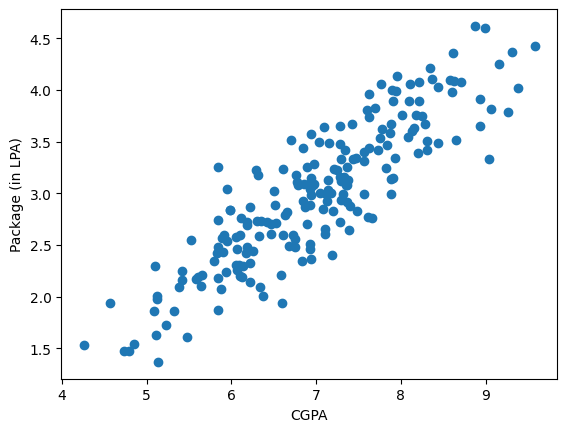

In [12]:
# Create a scatter plot to visualize relationship between CGPA and package
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')  # Label x-axis
plt.ylabel('Package (in LPA)')  # Label y-axis

In [13]:
# Prepare the data for machine learning
# X = features (independent variable) - taking all rows, first column only (cgpa)
# Using 0:1 instead of just 0 to keep it as 2D array (required for sklearn)
X = df.iloc[:, 0:1]  # Features: CGPA column
y = df.iloc[:, -1]   # Target: last column (package)

In [14]:
print(X, y, sep="\n\n************************\n\n")

     cgpa
0    6.89
1    5.12
2    7.82
3    7.42
4    6.94
..    ...
195  6.93
196  5.89
197  7.21
198  7.63
199  6.22

[200 rows x 1 columns]

************************

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64


In [15]:
# Import train-test split function
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%) sets
# random_state=2 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    X,          # Features/input data (CGPA values) - what we use to make predictions
    y,          # Target/output data (package values) - what we want to predict
    test_size=0.2,    # 20% of data goes to testing, 80% to training
    random_state=2    # Seed for random number generator - ensures reproducible splits
)

# What each variable contains after the split:
# X_train: 80% of CGPA values used for training the model
# X_test:  20% of CGPA values used for testing the model
# y_train: 80% of package values corresponding to X_train
# y_test:  20% of package values corresponding to X_test

In [16]:
# Import and create Linear Regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [17]:
# Train the model on training data
lr.fit(X_train, y_train)
# LinearRegression() - confirmation that model is created

LinearRegression()

In [18]:
# Display test features (CGPA values for testing)
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [19]:
# Display test target values (actual packages for testing)
y_test

,package
112,4.10
29,3.49
182,2.08
199,2.33
193,1.94
85,1.48
10,1.86
54,3.09
115,4.21
35,2.87


In [20]:
# Make prediction for a single test point
lr.predict(X_test.iloc[0].values.reshape(1,1))

# Breaking down each component:
# 1. X_test            - The dataframe containing test CGPA values (40 samples)
# 2. X_test.iloc[0]    - Selects the first row (index 0) from test data
#                      - This gives us a single CGPA value (8.58)
# 3. .values           - Converts the pandas Series/DataFrame to a numpy array
# 4. .reshape(1,1)     - Reshapes the array to have 1 row and 1 column
#                      - LinearRegression expects 2D input: (samples, features)
# 5. lr.predict()      - Uses trained model to predict package for this CGPA

# Visual representation of data transformation:
# X_test.iloc[0]           → 8.58 (as pandas Series)
# X_test.iloc[0].values    → array([8.58]) (1D array)
# X_test.iloc[0].values.reshape(1,1) → array([[8.58]]) (2D array with shape 1x1)

# The prediction output:
# array([3.89111601])      - Predicted package (in LPA) for CGPA 8.58

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package(in lpa)')

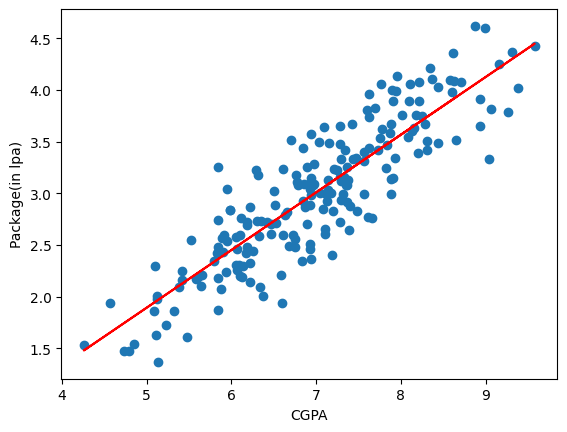

In [21]:
# Visualize the regression line
plt.scatter(df['cgpa'], df['package'])  # Plot all data points
plt.plot(X_train, lr.predict(X_train), color='red')  # Plot regression line using training data
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [22]:
# Extract model parameters
m = lr.coef_      # Slope (coefficient) of the regression line
b = lr.intercept_ # Intercept (where line crosses y-axis)
# y = mx + b - Linear equation formula

In [23]:
# Verify prediction using the equation y = mx + b
# For CGPA = 8.58, calculate predicted package
m * 8.58 + b
# array([3.89111601]) - matches the predict() output above

array([3.89111601])

In [24]:
# Predict package for CGPA = 9.5
m * 9.5 + b
# array([4.40443183])

array([4.40443183])

In [25]:
# Warning: Extrapolating too far from training data
# CGPA = 100 is unrealistic (training data is around 5-9)
# Shows why we shouldn't predict outside the range of training data
m * 100 + b
# array([54.89908542]) - Unrealistic prediction!

array([54.89908542])